<a href="https://colab.research.google.com/github/tungduong2106/PracticeML/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cost_matrix = np.array([[0,5],[1,0]])
print('Nếu tín dụng xấu được phân là xấu, chi phí: ', cost_matrix[0][0])
print('Nếu tín dụng xấu được phân là tốt, chi phí: ', cost_matrix[0][1])
print('Nếu tín dụng tốt được phân là xấu, chi phí: ', cost_matrix[1][0])
print('Nếu tín dụng tốt được phân là tốt, chi phí: ', cost_matrix[1][1])


Nếu tín dụng xấu được phân là xấu, chi phí:  0
Nếu tín dụng xấu được phân là tốt, chi phí:  5
Nếu tín dụng tốt được phân là xấu, chi phí:  1
Nếu tín dụng tốt được phân là tốt, chi phí:  0


In [4]:
data_array = np.genfromtxt('/content/drive/MyDrive/Colab Notebooks/german.data-numeric')
data_frame = df = pd.DataFrame(data_array, columns = ['A'+str(i) for i in range(1,25)] + ['label'])
data_frame['label'] = data_frame['label'].replace(2,0)
data_frame

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
0,1.0,6.0,4.0,12.0,5.0,5.0,3.0,4.0,1.0,67.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.0,48.0,2.0,60.0,1.0,3.0,2.0,2.0,1.0,22.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,4.0,12.0,4.0,21.0,1.0,4.0,3.0,3.0,1.0,49.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,1.0,42.0,2.0,79.0,1.0,4.0,3.0,4.0,2.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,24.0,3.0,49.0,1.0,3.0,3.0,4.0,4.0,53.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4.0,12.0,2.0,17.0,1.0,4.0,2.0,4.0,1.0,31.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
996,1.0,30.0,2.0,39.0,1.0,3.0,1.0,4.0,2.0,40.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
997,4.0,12.0,2.0,8.0,1.0,5.0,3.0,4.0,3.0,38.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
998,1.0,45.0,2.0,18.0,1.0,3.0,3.0,4.0,4.0,23.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      1000 non-null   float64
 1   A2      1000 non-null   float64
 2   A3      1000 non-null   float64
 3   A4      1000 non-null   float64
 4   A5      1000 non-null   float64
 5   A6      1000 non-null   float64
 6   A7      1000 non-null   float64
 7   A8      1000 non-null   float64
 8   A9      1000 non-null   float64
 9   A10     1000 non-null   float64
 10  A11     1000 non-null   float64
 11  A12     1000 non-null   float64
 12  A13     1000 non-null   float64
 13  A14     1000 non-null   float64
 14  A15     1000 non-null   float64
 15  A16     1000 non-null   float64
 16  A17     1000 non-null   float64
 17  A18     1000 non-null   float64
 18  A19     1000 non-null   float64
 19  A20     1000 non-null   float64
 20  A21     1000 non-null   float64
 21  A22     1000 non-null   float64
 22  A

In [6]:
data_frame.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A16,A17,A18,A19,A20,A21,A22,A23,A24,label
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,0.700000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000


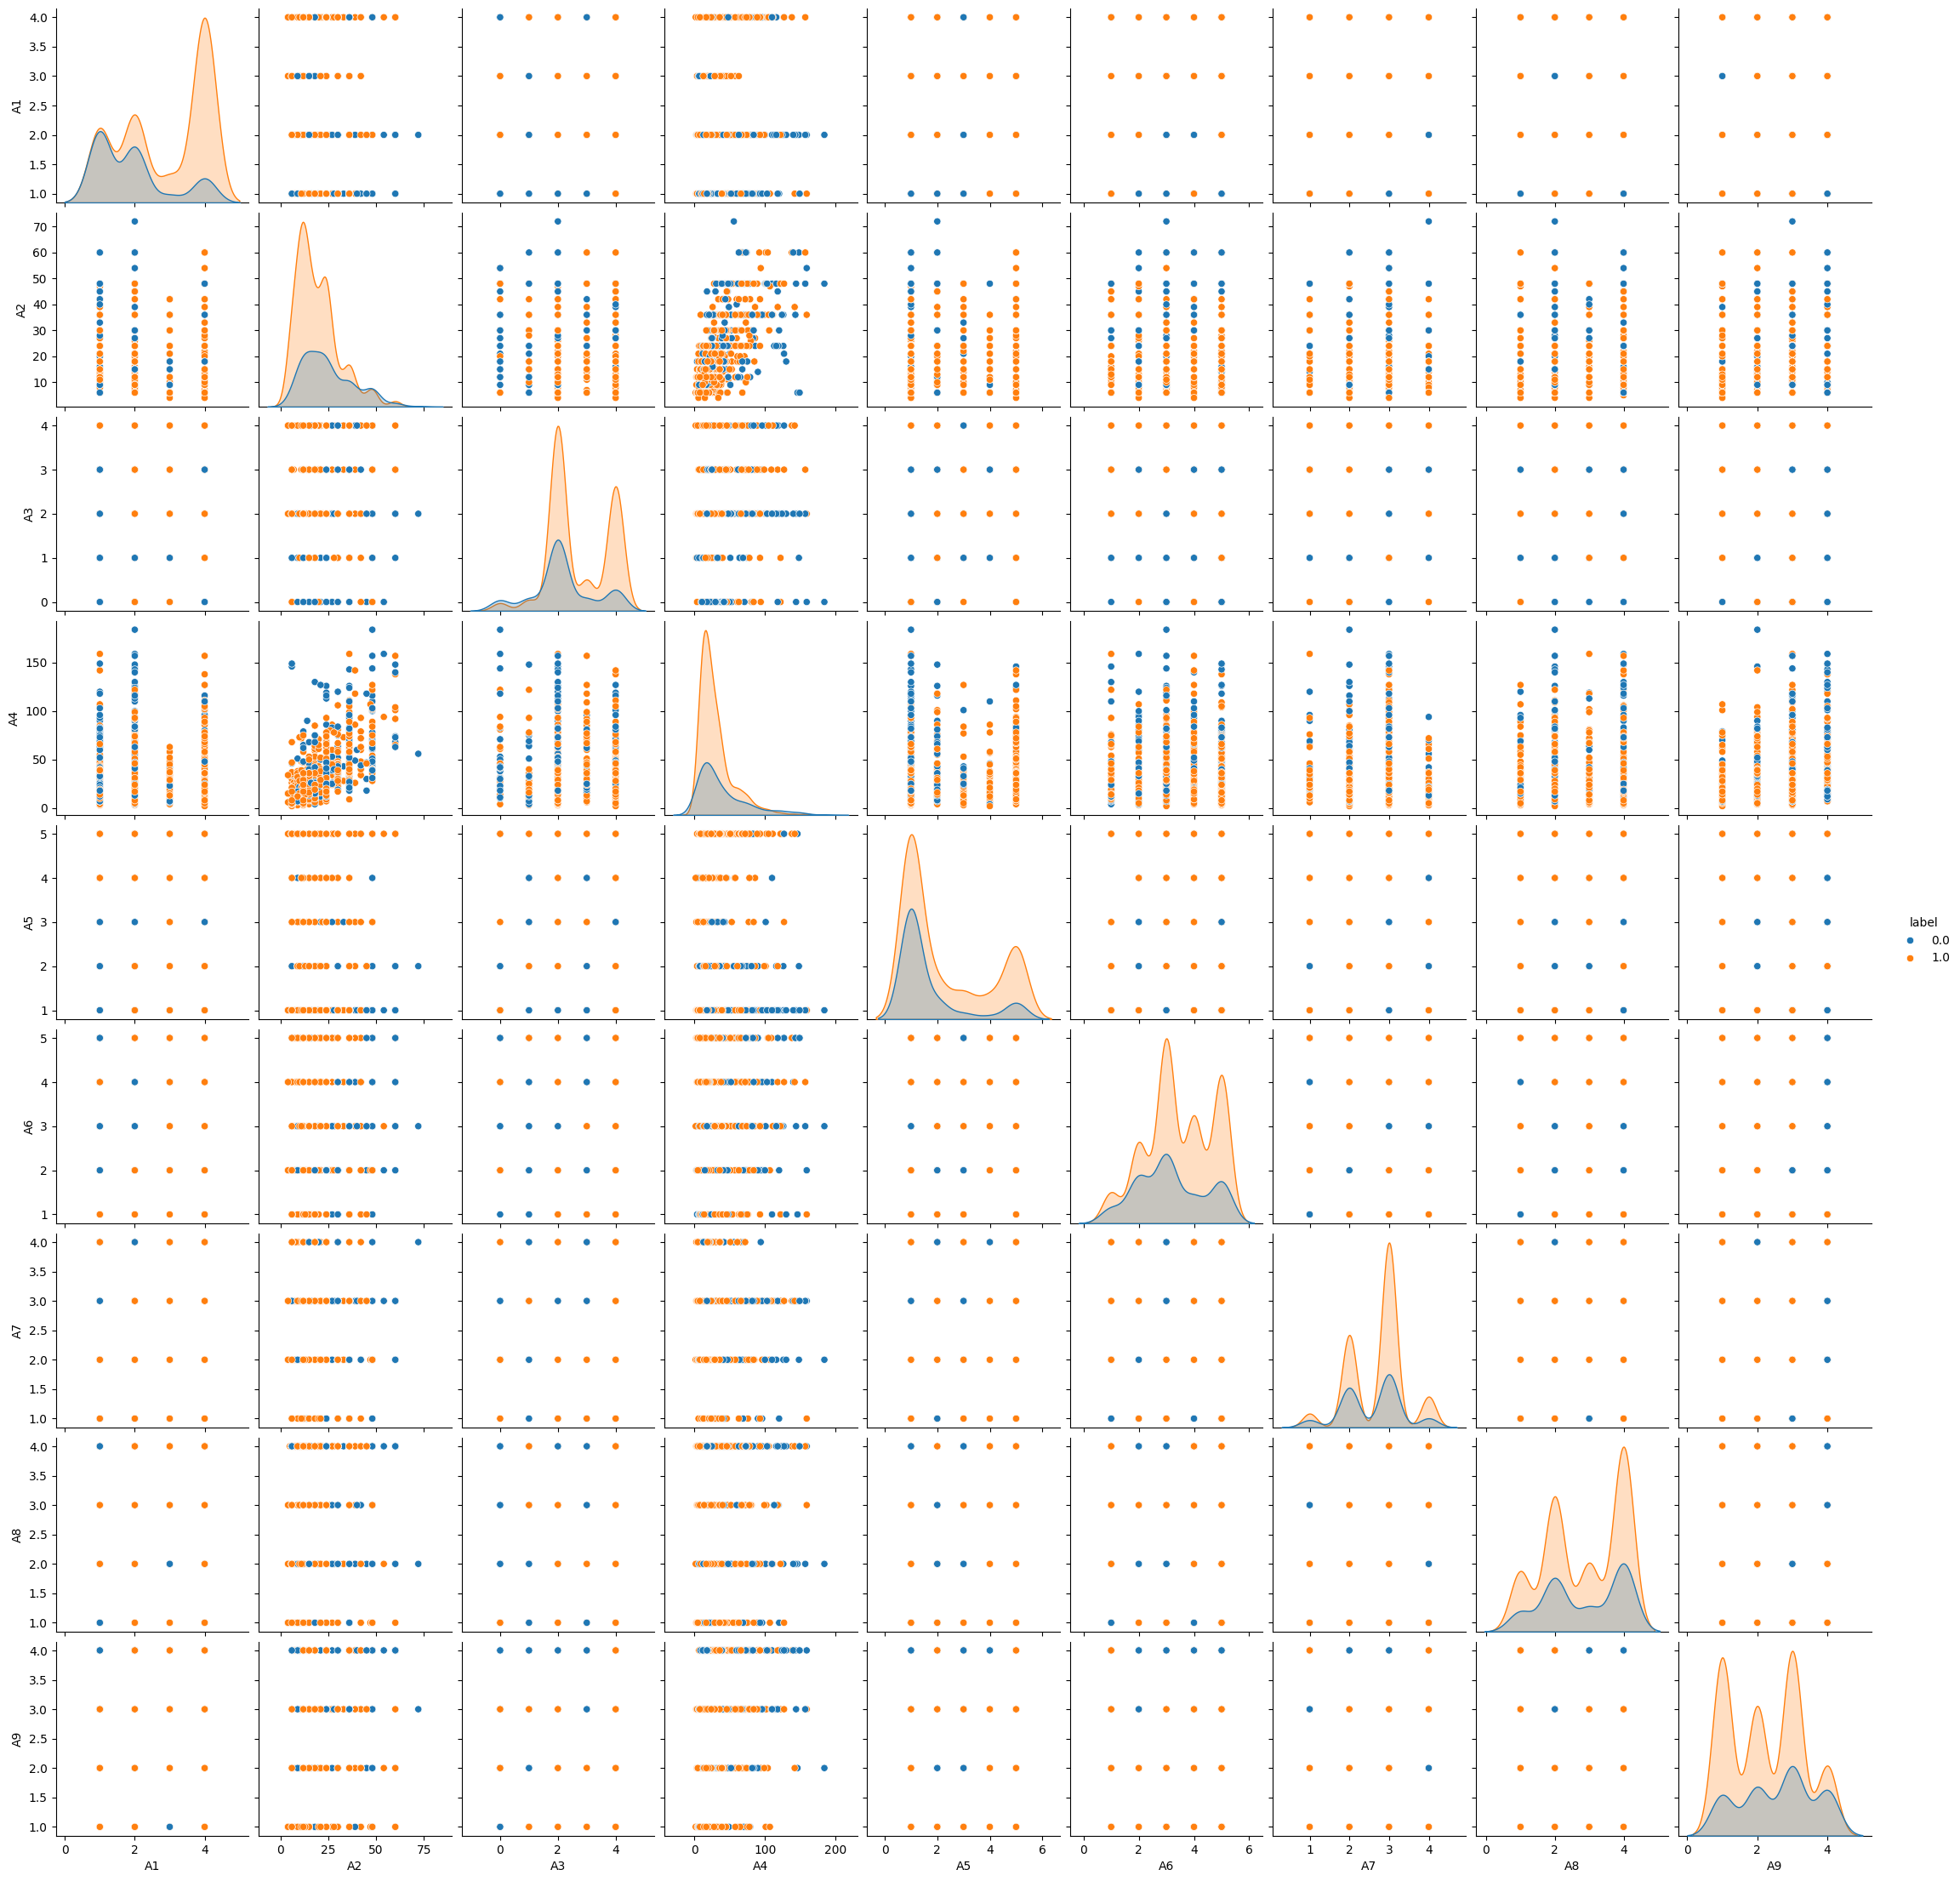

In [7]:
sns.pairplot(data_frame, hue='label', vars =['A'+str(i) for i in range(1,10)])

Câu lệnh này dùng seaborn để vẽ biểu đồ ma trận các cặp biến. hue='label': Màu sắc của các điểm sẽ được phân biệt theo giá trị của cột label (ví dụ: khách hàng tín dụng tốt vs xấu).vars=['A'+str(i) for i in range(1, 10)]: Chỉ chọn 9 cột đầu tiên (A1 → A9) để vẽ.Nghĩa là ta sẽ xem mối quan hệ giữa các cặp biến trong 9 feature đầu tiên.


<Axes: xlabel='label', ylabel='count'>

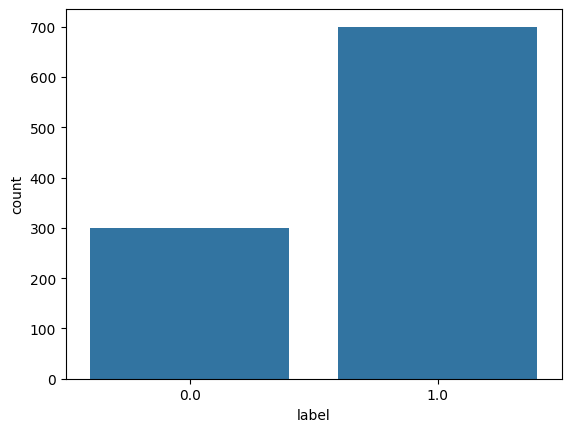

In [8]:
sns.countplot(x = data_frame['label'])

Câu lệnh này sẽ vẽ một biểu đồ cột (count plot) bằng thư viện Seaborn.
data_frame['label']: lấy cột label trong DataFrame, tức là nhãn phân loại (ví dụ: 1 = tín dụng tốt, 2 = tín dụng xấu).
sns.countplot(...): vẽ biểu đồ số lượng (count) của từng giá trị trong cột đó.

<Axes: >

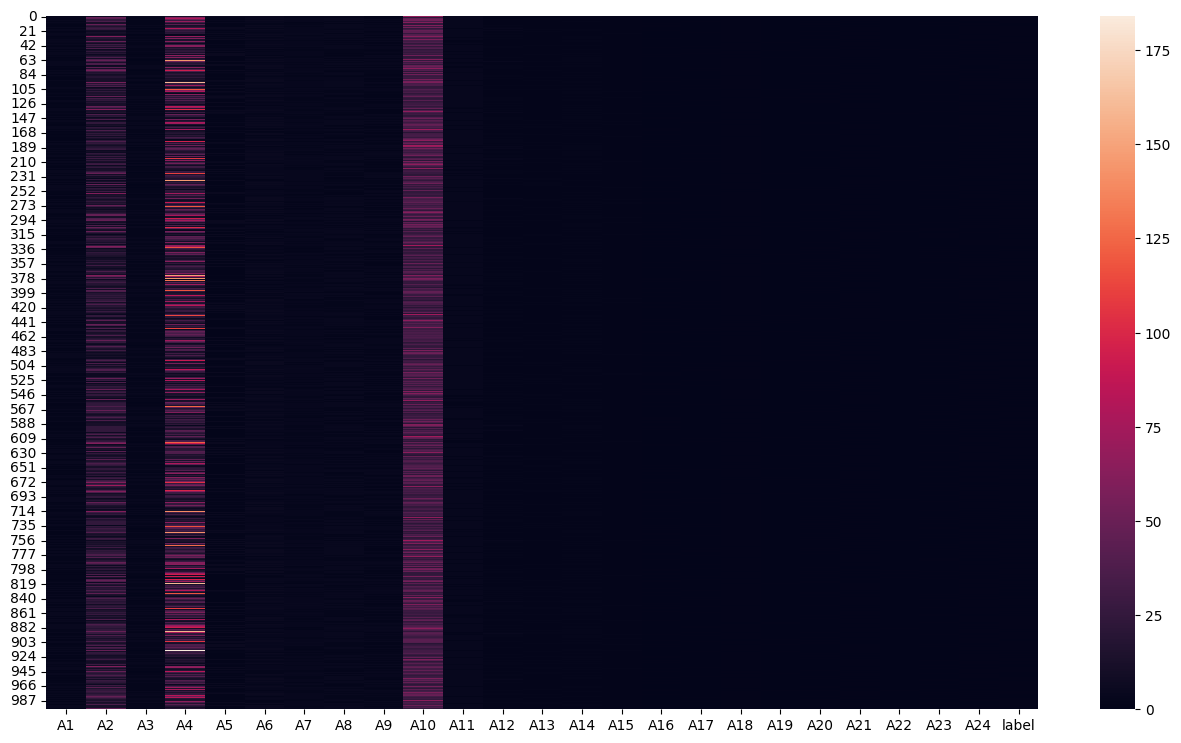

In [9]:
plt.figure(figsize=(16,9))
sns.heatmap(data_frame)

plt.figure(figsize=(16,9)): tạo một khung hình mới với kích thước 16×9 inch để vẽ biểu đồ, giúp biểu đồ rộng và dễ nhìn hơn.
sns.heatmap(data_frame): vẽ heatmap (bản đồ nhiệt) cho toàn bộ DataFrame.
Kết quả
Mỗi ô trong heatmap sẽ biểu diễn giá trị của một phần tử trong DataFrame bằng màu sắc.
Trục x: các cột (A1 → A24, label).
Trục y: các dòng (mỗi quan sát).
Màu sắc thể hiện giá trị số: giá trị nhỏ thì màu nhạt, giá trị lớn thì màu đậm.
Vấn đề thường gặp
Nếu DataFrame có nhiều dòng (ví dụ 1000 quan sát), heatmap sẽ rất dày đặc, khó đọc. Bạn sẽ thấy một “tấm thảm màu” thay vì thông tin hữu ích.
Heatmap thường dùng cho ma trận tương quan hoặc dữ liệu dạng ma trận nhỏ, chứ không phải toàn bộ dataset lớn.

<Axes: >

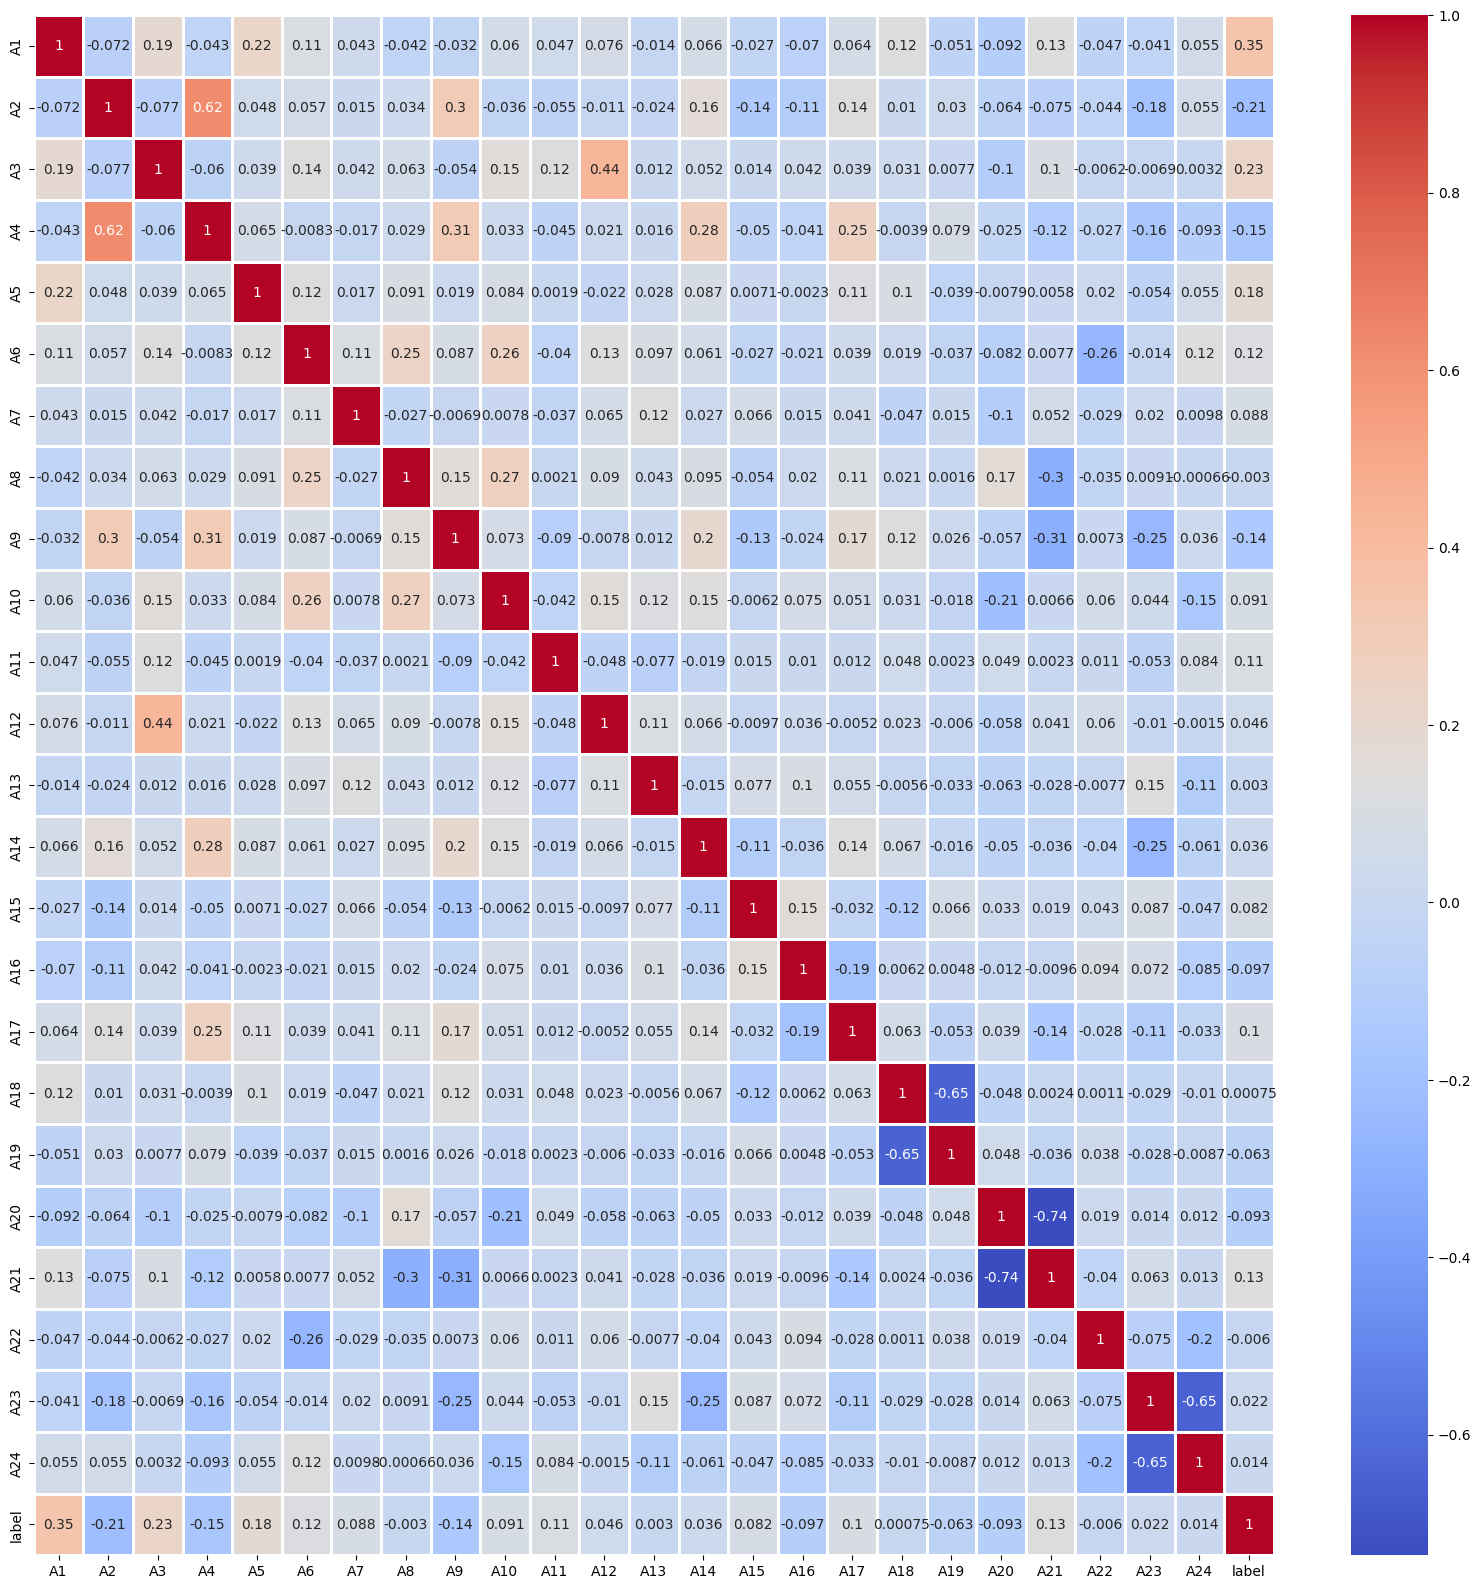

In [10]:
plt.figure(figsize=(20,20))
sns.heatmap(data_frame.corr(), annot=True, cmap ='coolwarm', linewidths=2)

plt.figure(figsize=(20,20)): tạo khung hình lớn (20×20 inch) để biểu đồ dễ nhìn, tránh chữ bị chồng chéo.

data_frame.corr(): tính ma trận tương quan giữa các cột trong DataFrame. Kết quả là một ma trận 25×25 (24 features + 1 label).

sns.heatmap(...): vẽ heatmap cho ma trận tương quan đó.

annot=True: hiển thị giá trị số (hệ số tương quan) ngay trên từng ô.

cmap='coolwarm': chọn bảng màu, thường màu đỏ cho tương quan âm, màu xanh cho tương quan dương.

linewidths=2: thêm đường viền giữa các ô để dễ phân biệt.

Kết quả hiển thị
Một ma trận màu 25×25, mỗi ô thể hiện mức độ tương quan giữa hai biến (giá trị từ -1 đến 1).

Đường chéo chính toàn giá trị 1 (vì mỗi biến tương quan hoàn toàn với chính nó).

Các ô ngoài đường chéo cho thấy mức độ liên hệ giữa các feature với nhau, và đặc biệt là giữa từng feature với label.

👉 Đây là cách trực quan để xem feature nào có liên hệ mạnh với nhãn (label), từ đó chọn lọc đặc trưng quan trọng cho mô hình.

In [11]:
X = data_frame.drop(['label'], axis = 1)
X = (X-X.min())/(X.max()-X.min()) # Chuẩn hóa X bằng Min - Max Scalling
X


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24
0,0.000000,0.029412,1.00,0.054945,1.00,1.00,0.666667,1.000000,0.000000,0.857143,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.333333,0.647059,0.50,0.318681,0.00,0.50,0.333333,0.333333,0.000000,0.053571,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.000000,0.117647,1.00,0.104396,0.00,0.75,0.666667,0.666667,0.000000,0.535714,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.000000,0.558824,0.50,0.423077,0.00,0.75,0.666667,1.000000,0.333333,0.464286,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.294118,0.75,0.258242,0.00,0.50,0.666667,1.000000,1.000000,0.607143,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.000000,0.117647,0.50,0.082418,0.00,0.75,0.333333,1.000000,0.000000,0.214286,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
996,0.000000,0.382353,0.50,0.203297,0.00,0.50,0.000000,1.000000,0.333333,0.375000,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
997,1.000000,0.117647,0.50,0.032967,0.00,1.00,0.666667,1.000000,0.666667,0.339286,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
998,0.000000,0.602941,0.50,0.087912,0.00,0.50,0.666667,1.000000,1.000000,0.071429,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
X.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000
mean,0.525667,0.248574,0.63625,0.168742,0.276250,0.596000,0.560667,0.615000,0.452667,0.295464,...,0.037000,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000
std,0.419213,0.177336,0.27078,0.155234,0.395006,0.302077,0.236027,0.367906,0.350070,0.203133,...,0.188856,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,0.000000,0.117647,0.50000,0.065934,0.000000,0.500000,0.333333,0.333333,0.000000,0.142857,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
50%,0.333333,0.205882,0.50000,0.115385,0.000000,0.500000,0.666667,0.666667,0.333333,0.250000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000
75%,1.000000,0.294118,1.00000,0.208791,0.500000,1.000000,0.666667,1.000000,0.666667,0.410714,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000


<Axes: >

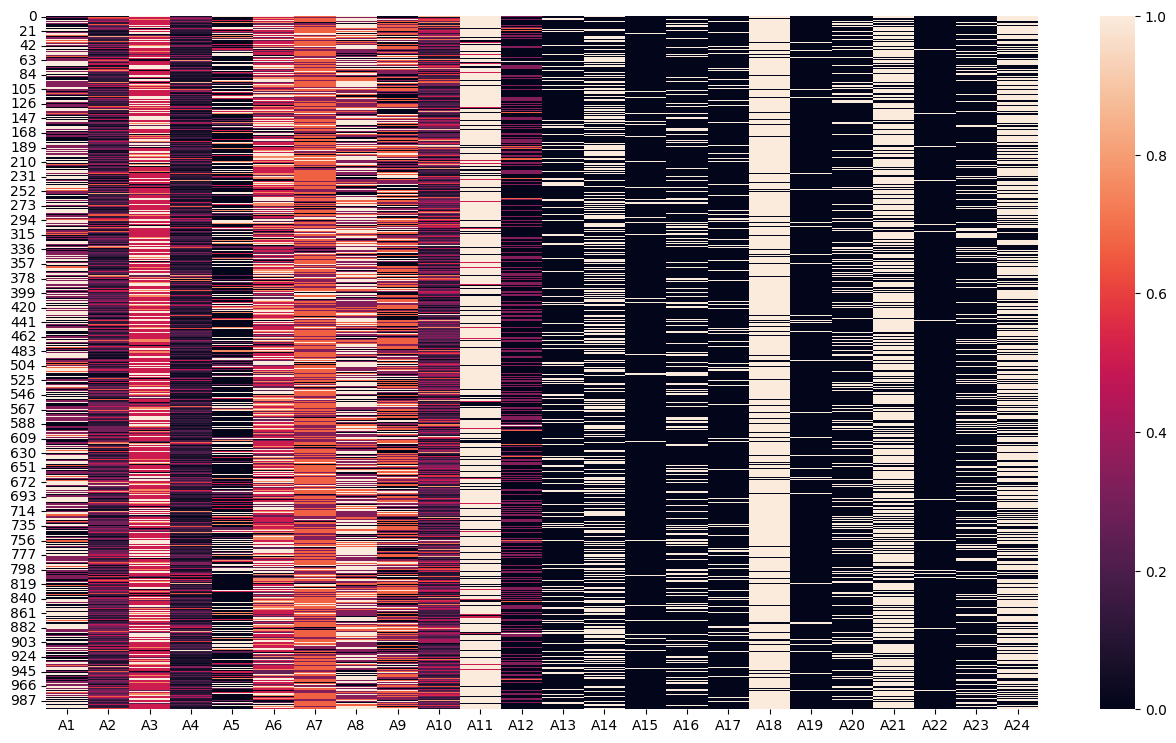

In [13]:
plt.figure(figsize=(16,9))
sns.heatmap(X)

In [14]:
y = data_frame['label']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)

Dữ liệu training =  (800, 24) (800,)
Dữ liệu testing =  (200, 24) (200,)


In [16]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
%matplotlib inline

%matplotlib inline

Đây là magic command của Jupyter Notebook.

Nó yêu cầu Jupyter hiển thị trực tiếp các biểu đồ matplotlib ngay trong ô notebook (inline), thay vì mở cửa sổ đồ họa riêng.

Nhờ đó, khi bạn gọi plt.plot(...), sns.heatmap(...) hay bất kỳ biểu đồ nào, kết quả sẽ xuất hiện ngay dưới cell code.

Tại sao cần dùng
Nếu không có %matplotlib inline, đôi khi biểu đồ sẽ không hiển thị trong notebook, hoặc phải gọi thêm plt.show().

Với %matplotlib inline, mọi biểu đồ matplotlib được vẽ sẽ tự động hiển thị, rất tiện cho việc phân tích dữ liệu trong Jupyter.

In [17]:
knn = KNeighborsClassifier(n_neighbors=10, metric = 'minkowski', p=2, weights='distance')
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10, weights='distance')

KNeighborsClassifier(...)

Đây là cách khởi tạo mô hình K-Nearest Neighbors (KNN) trong thư viện scikit-learn.

Các tham số bạn chọn:

n_neighbors=10: khi dự đoán, mô hình sẽ xét 10 điểm láng giềng gần nhất.

metric='minkowski', p=2: dùng khoảng cách Minkowski với p=2.

Khi p=2, công thức trở thành khoảng cách Euclidean (khoảng cách chuẩn).

weights='distance': các láng giềng được trọng số theo khoảng cách. Nghĩa là láng giềng gần hơn có ảnh hưởng lớn hơn đến dự đoán, láng giềng xa hơn ảnh hưởng ít hơn.

In [18]:
# Cost function
def cost(y_true, y_pred):
  true_pos = ((y_true==y_pred)&(y_true==1.0))*0.0
  true_ne = ((y_true==y_pred)&(y_true==0.0))*0.0
  false_ne = ((y_true!=y_pred)&(y_true==1.0))*1.0
  false_pos = ((y_true!=y_pred)&(y_true==0.0))*5.0
  return sum(true_pos + true_ne + false_pos + false_ne)

Giải thích
Hàm này định nghĩa một hàm chi phí (cost function) tuỳ chỉnh để đánh giá mô hình phân loại nhị phân.

Nó dựa trên việc so sánh nhãn thật (y_true) và nhãn dự đoán (y_pred).

Các biến trung gian
true_pos: trường hợp dự đoán đúng và nhãn thật = 1.0 → chi phí = 0.0.

true_ne: trường hợp dự đoán đúng và nhãn thật = 0.0 → chi phí = 0.0.

false_ne: trường hợp dự đoán sai khi nhãn thật = 1.0 (false negative) → chi phí = 1.0.

false_pos: trường hợp dự đoán sai khi nhãn thật = 0.0 (false positive) → chi phí = 5.0.

Ý nghĩa
Hàm này coi false positive (dự đoán khách hàng tốt nhưng thực tế xấu) là lỗi nghiêm trọng hơn, nên phạt nặng (5.0).

false negative (dự đoán khách hàng xấu nhưng thực tế tốt) thì phạt nhẹ hơn (1.0).

Dự đoán đúng thì không phạt (0.0).

Kết quả trả về
Tính tổng chi phí của tất cả các mẫu, rồi chia cho số lượng mẫu (len(y_true)), tức là chi phí trung bình trên toàn bộ tập dữ liệu.

In [19]:
print("Testing...\n")
y_pred_knn = knn.predict(X_test)
print("Accurary : ",accuracy_score(y_test, y_pred_knn))
print("Cost : ", cost(y_test, y_pred_knn))

Testing...

Accurary :  0.76
Cost :  172.0


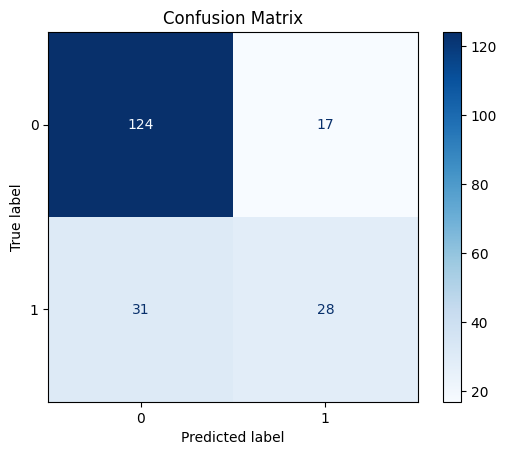

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_knn, labels =[1,0])
disc = ConfusionMatrixDisplay(confusion_matrix=cm)
disc.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
#

Số lượng hàng xóm:  1
Accurary :  0.665
Cost :  191.0

Số lượng hàng xóm:  2
Accurary :  0.665
Cost :  191.0

Số lượng hàng xóm:  3
Accurary :  0.765
Cost :  147.0

Số lượng hàng xóm:  4
Accurary :  0.76
Cost :  156.0

Số lượng hàng xóm:  5
Accurary :  0.74
Cost :  176.0

Số lượng hàng xóm:  6
Accurary :  0.74
Cost :  188.0

Số lượng hàng xóm:  7
Accurary :  0.695
Cost :  213.0

Số lượng hàng xóm:  8
Accurary :  0.735
Cost :  193.0

Số lượng hàng xóm:  9
Accurary :  0.73
Cost :  198.0

Số lượng hàng xóm:  10
Accurary :  0.76
Cost :  172.0

Số lượng hàng xóm:  11
Accurary :  0.735
Cost :  197.0

Số lượng hàng xóm:  12
Accurary :  0.75
Cost :  190.0

Số lượng hàng xóm:  13
Accurary :  0.74
Cost :  192.0

Số lượng hàng xóm:  14
Accurary :  0.73
Cost :  202.0

Số lượng hàng xóm:  15
Accurary :  0.735
Cost :  197.0

Số lượng hàng xóm:  16
Accurary :  0.745
Cost :  199.0

Số lượng hàng xóm:  17
Accurary :  0.755
Cost :  185.0

Số lượng hàng xóm:  18
Accurary :  0.76
Cost :  188.0

Số lượng h

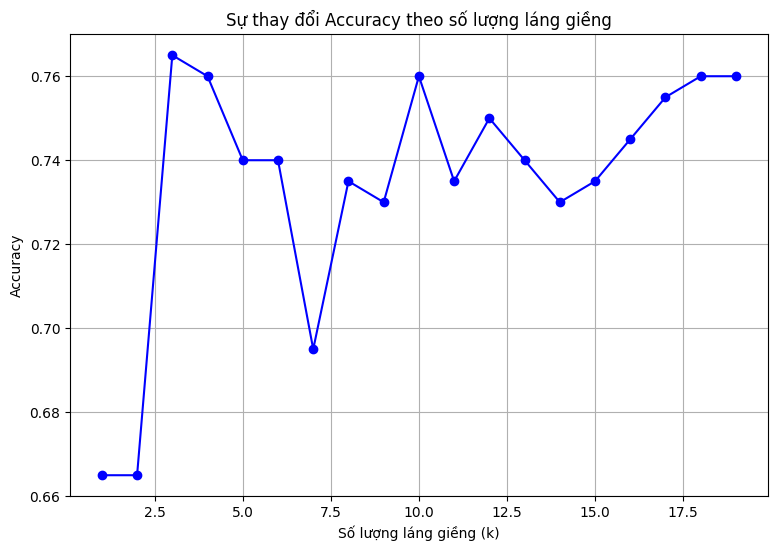

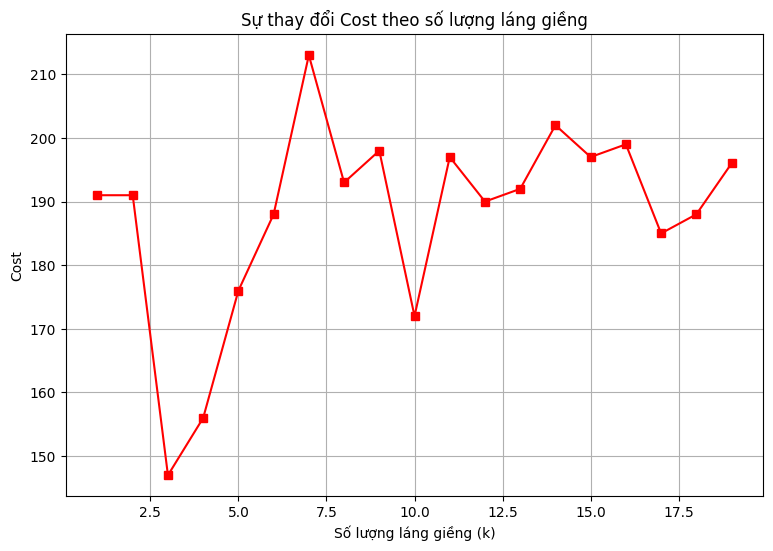

In [21]:
# Thay đổi số lượng láng giềng
accuracies = []
costs = []
neighbors = range(1, 20)
for i in range(1, 20):
  knn = KNeighborsClassifier(n_neighbors= i, metric = 'minkowski', p=2, weights='distance')
  knn.fit(X_train, y_train)
  print("Số lượng hàng xóm: ",i)
  y_pred_knn = knn.predict(X_test)
  print("Accurary : ",accuracy_score(y_test, y_pred_knn))
  print("Cost : ", cost(y_test, y_pred_knn))
  print()
  accuracies.append(accuracy_score(y_test, y_pred_knn))
  costs.append(cost(y_test, y_pred_knn))
# Vẽ biểu đồ Accuracy
plt.figure(figsize=(9,6))
plt.plot(neighbors, accuracies, marker='o', color='blue')
plt.title("Sự thay đổi Accuracy theo số lượng láng giềng")
plt.xlabel("Số lượng láng giềng (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()
print()
# Vẽ biểu đồ Cost
plt.figure(figsize=(9,6))
plt.plot(neighbors, costs, marker='s', color='red')
plt.title("Sự thay đổi Cost theo số lượng láng giềng")
plt.xlabel("Số lượng láng giềng (k)")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [22]:
# Thử loại bỏ thuộc tính
for i in range(1, 25):
    # Loại bỏ label và cột Ai
    X = data_frame.drop(columns=['label', 'A'+str(i)], axis = 1)
    y = data_frame['label']

    X = (X - X.min()) / (X.max() - X.min())
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=10, metric='minkowski', p=2, weights='distance')
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("Loại bỏ "'A'+str(i))
    print("Accurary : ",accuracy_score(y_test, y_pred))
    print("Cost : ", cost(y_test, y_pred))

Loại bỏ A1
Accurary :  0.68
Cost :  252.0
Loại bỏ A2
Accurary :  0.74
Cost :  192.0
Loại bỏ A3
Accurary :  0.735
Cost :  193.0
Loại bỏ A4
Accurary :  0.74
Cost :  188.0
Loại bỏ A5
Accurary :  0.725
Cost :  207.0
Loại bỏ A6
Accurary :  0.77
Cost :  178.0
Loại bỏ A7
Accurary :  0.735
Cost :  205.0
Loại bỏ A8
Accurary :  0.715
Cost :  201.0
Loại bỏ A9
Accurary :  0.745
Cost :  191.0
Loại bỏ A10
Accurary :  0.755
Cost :  173.0
Loại bỏ A11
Accurary :  0.725
Cost :  207.0
Loại bỏ A12
Accurary :  0.765
Cost :  167.0
Loại bỏ A13
Accurary :  0.735
Cost :  189.0
Loại bỏ A14
Accurary :  0.76
Cost :  172.0
Loại bỏ A15
Accurary :  0.745
Cost :  187.0
Loại bỏ A16
Accurary :  0.73
Cost :  182.0
Loại bỏ A17
Accurary :  0.76
Cost :  188.0
Loại bỏ A18
Accurary :  0.735
Cost :  201.0
Loại bỏ A19
Accurary :  0.765
Cost :  167.0
Loại bỏ A20
Accurary :  0.755
Cost :  185.0
Loại bỏ A21
Accurary :  0.77
Cost :  178.0
Loại bỏ A22
Accurary :  0.755
Cost :  173.0
Loại bỏ A23
Accurary :  0.735
Cost :  193.0
Loại 

In [23]:
# Hàm tình khoảng cách manhattan
knn = KNeighborsClassifier(n_neighbors= 10, metric = 'manhattan', p=2, weights='distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accurary : ",accuracy_score(y_test, y_pred_knn))
print("Cost : ", cost(y_test, y_pred_knn))
print()

Accurary :  0.705
Cost :  215.0



In [24]:
# Hàm tình khoảng cách euclidean
knn = KNeighborsClassifier(n_neighbors= 10, metric = 'euclidean', p=2, weights='distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accurary : ",accuracy_score(y_test, y_pred_knn))
print("Cost : ", cost(y_test, y_pred_knn))
print()

Accurary :  0.75
Cost :  190.0



In [25]:
# Hàm tình khoảng cách chebyshev
knn = KNeighborsClassifier(n_neighbors= 10, metric = 'chebyshev', p=2, weights='distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("Accurary : ",accuracy_score(y_test, y_pred_knn))
print("Cost : ", cost(y_test, y_pred_knn))
print()

Accurary :  0.625
Cost :  167.0

